# Flat arena experiment 

Test of the 2D network on a flat arena.



In [1]:
import os
import sys
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))

from config import RunConfig, PlaneConfig, NetworkConfig
from experiments.arena_2d import Arena2DExperiment, Arena2DConfig
from analysis.scoring import (
    occupancy_fraction, summarize_2d, apply_hgs_floor,
    score_2d_from_map, percentile_cells,
)
from model.network.visualize3D import plot_pi_error
from model.plane_estimation import held_normal_stats


## 2. Settings

Every number that can change lives here. Each run is one pair from `KAPPA_SENS_VALUES` and `TAU_REFRESH_VALUES`.

The steps and the size of the arena are set here. The network configuration was searched in the 4_sweep_parameters_2d notebook. κ is perceptual certainty; the likelihood κ is set equal to κ_sens on each run. The grid stops at 10: below that, draws land in the lower hemisphere.

Rate maps and the shift-shuffle maps are built for every cell on the sheet (3,969 at this spacing). `N_SUB = 0` means that full axis. Scoring later drops silent cells, but those indices still refer to the same columns in the real map and in the shuffles.


In [1]:
# --- arena and walk ---
N_STEPS      = 1_000_000
ENV_SIZE     = 2.0
GRID_SPACING = 0.48          # metres per field spacing; arena is ~4.17 periods
TARGET_SPEED = 0.002
SEEDS        = (0,)

# --- plane sweep (one run per pair) ---
KAPPA_SENS_VALUES  = (1000.0, 300.0, 30.0, 10.0)
TAU_REFRESH_VALUES = (1, 10, 100)
KAPPA_W            = 1e4
MEASUREMENT        = "sensed"

# --- network ---
net = NetworkConfig(
    spacing=0.1,
    dim=2,
    lambda_net=1.28,
    ratio=1.05,
    alpha=1.806,
    b=1.0,
    offset_magnitude=0.196,
    dt=0.25,
    tau=5.0,
    velocity_gain=2.626,
    bump_spacing_cells=19.8,
    settle_steps=4000,
    build_connectivity=False,
)

# --- scoring ---
RATEMAP_BINS     = 40
N_SUB            = 0          # 0 = every cell; shuffle maps use that same axis
N_SHUFFLE        = 100       # circular position-activity shifts for HGS chance
RECORD           = False
G_VEC            = np.array([0.0, 0.0, -9.81])

print("velocity_gain", net.velocity_gain, "field_spacing", net.bump_spacing_cells)
print("settle_steps", net.settle_steps)


NameError: name 'NetworkConfig' is not defined

## 3. Network

Build the experiment. 


In [ ]:
plane = PlaneConfig(
    kappa=KAPPA_SENS_VALUES[0], kappa_w=KAPPA_W,
    kappa_sens=KAPPA_SENS_VALUES[0],
    measurement=MEASUREMENT, plane_mode="bayesian",
    tau_refresh=TAU_REFRESH_VALUES[0], seed=0,
)
exp_cfg = Arena2DConfig(
    env_size=ENV_SIZE, n_steps=N_STEPS, seed=SEEDS[0],
    grid_spacing=GRID_SPACING, target_speed_rad_per_time=TARGET_SPEED,
    record=RECORD, ratemap_bins=RATEMAP_BINS,
    ratemap_n_sub=N_SUB, ratemap_n_shuffle=N_SHUFFLE,
)
cfg = RunConfig(network=net, experiment=exp_cfg, plane=plane)
exp = Arena2DExperiment(cfg, record=RECORD)


[arena_2d] neurons 3,969 arena 2.0 m | grid_period 0.48 m | periods 4.17


## 4. Trajectory

Generate the walk once per seed and reuse it for every (κ_sens, τ) pair. The figure shows coverage; occupancy in the title is the fraction of bins visited.


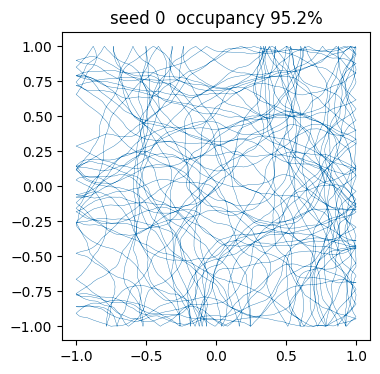

In [4]:
def make_walk(seed):
    exp.config.experiment.seed = int(seed)
    return exp.generate_trajectory(seed=int(seed), n_steps=N_STEPS)

traj0 = make_walk(SEEDS[0])
occ0 = occupancy_fraction(traj0.world_pos, ENV_SIZE, RATEMAP_BINS)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(traj0.world_pos[:, 0], traj0.world_pos[:, 1], lw=0.3)
ax.set_aspect("equal")
ax.set_title(f"seed {SEEDS[0]}  occupancy {occ0:.1%}")
plt.show()


## 5. Runs

We run the same walk for all the different plane parameters. The score should here be pretty consitent between different plane estimation parameterts.


In [ ]:
def apply_plane(kappa_sens, tau_refresh):
    """PathIntegrator is built from integrator_kwargs, copied at startup."""
    exp.config.plane.kappa = float(kappa_sens)
    exp.config.plane.kappa_sens = float(kappa_sens)
    exp.config.plane.tau_refresh = int(tau_refresh)
    exp.integrator_kwargs["kappa"] = float(kappa_sens)
    exp.integrator_kwargs["kappa_sens"] = float(kappa_sens)
    exp.integrator_kwargs["tau_refresh"] = int(tau_refresh)

SCORE_KW = dict(hgs_thresh=None)

runs = {}
#Set up the different seed parameters
for seed in SEEDS:
    #same walk for all seed parameters
    traj = make_walk(seed)
    #same network parameters for all seed parameters
    exp.config.experiment.seed = int(seed)
    world_pos, v_body, torus_gt = traj
    n_true = getattr(traj, "n_true_seq", None)
    starts = getattr(traj, "segment_starts", None)
    
    #Loop through different kappa and refers values and run the experiment for each pair
    for kappa_sens in KAPPA_SENS_VALUES:
        for tau_refresh in TAU_REFRESH_VALUES:
            print(f"\n=== seed {seed}  κ_sens {kappa_sens:g}  τ {tau_refresh} ===")
            apply_plane(kappa_sens, tau_refresh)
            res = exp.run(
                world_pos, v_body, torus_gt, G_VEC,
                n_true_seq=n_true, segment_starts=starts,
                plane_mode="bayesian",
            )
            
            #score the spesific experiment config.
            scores = score_2d_from_map(
                res.ratemap_sums, res.ratemap_counts,
                active_mask=res.active_mask, occ_warn=0.0,
                shuf_sums=res.shuf_sums, **SCORE_KW)
            floor = scores["hgs_shuf_p95"]
            #Shuffle to check for chance 95%
            apply_hgs_floor(scores, floor, require_hgs_gt_sgs=True)
            if n_true is None:
                n_true_arr = np.broadcast_to(
                    np.array([0.0, 0.0, 1.0]), (len(world_pos), 3))
            else:
                n_true_arr = np.asarray(n_true, dtype=float)
            refresh = np.arange(len(world_pos)) % max(int(tau_refresh), 1) == 0
            
            #Get the stats for the filter
            stats = held_normal_stats(res.n_held_hist, n_true_arr, refresh)
            
            #Summarize the results
            row = summarize_2d(scores)
            print(f"median HGS {row['median_hgs']:.3f}  "
                  f"final error {res.norm_error[-1]:.4f}  "
                  f"shift-shuffle p95={floor:.3f}")
            runs[(int(seed), float(kappa_sens), int(tau_refresh))] = dict(
                result=res, scores=scores, row=row,
                filter_stats=stats, floor=floor,
            )

SHOW = (SEEDS[0], 300.0, 1)
out = runs[SHOW]
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(out["result"].warmup_volume, origin="lower")
ax.set_title(f"settled sheet  κ_sens {SHOW[1]:g}  τ {SHOW[2]}")
ax.axis("off")
plt.show()


NameError: name 'os' is not defined

## 6. Path-integration accuracy

Final field-spacing error against κ_sens, one line per refresh interval. The error is one field spacing, not a fraction of 2π.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for tau in TAU_REFRESH_VALUES:
    ys = [runs[(SEEDS[0], float(k), int(tau))]["result"].norm_error[-1]
          for k in KAPPA_SENS_VALUES]
    ax.plot(KAPPA_SENS_VALUES, ys, marker="o", label=f"τ={tau}")
ax.set_xscale("log")
ax.set_xlabel("κ_sens")
ax.set_ylabel("final error (field spacings)")
ax.set_title(f"seed {SEEDS[0]}  field-spacing error")
ax.legend()
fig.tight_layout()
plt.show()


## 7. Path integration

Decoded torus position against ground truth for the run at κ_sens = 300, τ = 1. The printed RMS is the held-normal error, not the κ you set. Gravity folds start below κ ≈ 10.


In [ ]:
res = out["result"]
fig, axes = plot_pi_error(res.torus_gt, res.theta_hist)
plt.show()
stats = out["filter_stats"]
print(f"κ_sens {SHOW[1]:g}  τ {SHOW[2]}  "
      f"rms={stats['rms_err_deg']:.2f} deg  "
      f"mean_rate={stats['mean_rate_deg']:.3f} deg/step  "
      f"refreshes={stats['refresh_count']}")
print(f"n_gravity_flips={res.n_gravity_flips}")


## 8. Scoring

One row per (κ_sens, τ_refresh). Chance HGS is that run's shift and shuffle 95%.



In [ ]:
rows = []
for (seed, kappa_sens, tau_refresh), run in runs.items():
    res = run["result"]
    rows.append(dict(
        seed=seed, kappa_sens=kappa_sens, tau_refresh=tau_refresh,
        final_error=float(res.norm_error[-1]),
        tracking_score=float(res.mean_norm_error),
        rms_err_deg=run["filter_stats"]["rms_err_deg"],
        hgs_floor=run["floor"],
        **run["row"],
    ))
display(pd.DataFrame(rows))


## 9. Figures

Two figures for κ_sens = 300, τ = 1. (a) Per-cell HGS and SGS with that run's shift-shuffle floor. (b) Rate maps and autocorrelograms at the 10th, 50th and 90th percentile of HGS.


In [ ]:
sc = out["scores"]
floor = out["floor"]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(sc["hgs"], bins=20, alpha=0.7, label="HGS")
ax.hist(sc["sgs"], bins=20, alpha=0.5, label="SGS")
ax.axvline(floor, color="k", ls="--", label=f"shift-shuffle p95={floor:.3f}")
ax.set_xlabel("gridness")
ax.set_title(f"κ_sens {SHOW[1]:g}  τ {SHOW[2]}  per-cell gridness")
ax.legend()
fig.tight_layout()
plt.show()

percentiles = (10, 50, 90)
idx = percentile_cells(sc["hgs"], percentiles)
f, ac = sc["f"], sc["ac"]
fig, axes = plt.subplots(2, len(idx), figsize=(3.2 * len(idx), 6))
if len(idx) == 1:
    axes = np.array(axes).reshape(2, 1)
for j, k in enumerate(idx):
    axes[0, j].imshow(f[..., k], origin="lower")
    axes[0, j].set_title(f"p{percentiles[j]}  HGS={sc['hgs'][k]:.3f}")
    axes[0, j].axis("off")
    axes[1, j].imshow(ac[..., k], origin="lower")
    axes[1, j].axis("off")
axes[0, 0].set_ylabel("rate map")
axes[1, 0].set_ylabel("autocorr")
fig.suptitle(f"κ_sens {SHOW[1]:g}  τ {SHOW[2]}  cells at HGS percentiles")
fig.tight_layout()
plt.show()
